# Example — GILGFVFTL / HLA-A*02:01 and the CDR3β Arg–Ser motif

The influenza M1₅₈₋₆₆ epitope **GILGFVFTL** presented by **HLA-A*02:01** is recognised by a
strongly biased, public T-cell response built on TRBV19, whose hallmark is a conserved
**Arg–Ser (RS) motif** in CDR3β. The canonical structure is the **JM22** TCR (PDB **1oga**),
with CDR3β `ASSSRSSYEQY` — the Arg and the following Ser reach into the peptide.

This public RS motif is documented in **VDJdb** (Shugay M, Bagaev DV, Zvyagin IV, *et al.*,
*Nucleic Acids Research* 2018;46(D1):D419–D427, https://doi.org/10.1093/nar/gkx760; record
retrieved from PubMed, PMID 28977646). Here we orient 1oga into the canonical frame and use the
tcren complementarity maps to show *where* the Arg–Ser residues contact the peptide. The
structure is read only from the bootstrapped HF `Native2026` set.

In [1]:
# Load the JM22 complex (1oga) from the HF set, type chains (arda), annotate the MHC groove.
import warnings; warnings.filterwarnings('ignore')
import sys
from pathlib import Path
import numpy as np, polars as pl, matplotlib, matplotlib.pyplot as plt
import tcren
from tcren.structure.io import import_structure
from tcren.annotation import classify_chains
from tcren.mhc import annotate_mhc
from tcren.orient import docking_angles
from tcren.project2d import (project_structure, residue_markup_table, contacts_table,
                             ca_contacts_table, pocket_markers, region_pair_contacts)
from tcren.viz import render_complementarity_map
from IPython.display import SVG, display
print('python', sys.version.split()[0], '| tcren', tcren.__version__)

s = import_structure(Path('data/Native2026/1oga.pdb.gz'), pdb_id='1oga')
classify_chains(s, organism='human'); annotate_mhc(s)
cdr3b = next(r.sequence for c in s.chains if c.chain_type == 'TRB'
             for r in c.regions if r.region_type == 'CDR3')
pep = next(c.sequence() for c in s.chains if c.chain_type == 'PEPTIDE')
ang = docking_angles(s)
print(f'peptide={pep}  CDR3β={cdr3b}  crossing={ang.crossing_angle:.0f}° incident={ang.incident_angle:.0f}°')

python 3.11.15 | tcren 0.1.0


peptide=GILGFVFTL  CDR3β=ASSSRSSYEQY  crossing=83° incident=-14°


## Where does the Arg–Ser motif touch the peptide?

In [2]:
# CDR3β → peptide contacts, annotated with the CDR3β residue identity; flag the Arg/Ser motif.
markup = residue_markup_table(s)
# aa per (complex_chain, region, aa_index) lookup for labelling contact ends.
aa_at = {(r['complex_chain'], r['complex_region'], r['aa_index']): (r['aa'], r['residue_index'])
         for r in markup.iter_rows(named=True)}
rp = region_pair_contacts(s, kind='closest')
cdr3b_pep = rp.filter(
    (((pl.col('complex_chain_1') == 'trb') & (pl.col('region_1') == 'cdr3') & (pl.col('complex_chain_2') == 'peptide')) |
     ((pl.col('complex_chain_2') == 'trb') & (pl.col('region_2') == 'cdr3') & (pl.col('complex_chain_1') == 'peptide'))))
rows = []
for r in cdr3b_pep.iter_rows(named=True):
    # orient so end 1 = CDR3β, end 2 = peptide
    if r['complex_chain_1'] == 'trb':
        tcr_aa, tcr_resi = aa_at.get(('trb', 'cdr3', r['aa_index_1']), ('?', None))
        pep_aa, pep_resi = aa_at.get(('peptide', 'peptide', r['aa_index_2']), ('?', None))
    else:
        tcr_aa, tcr_resi = aa_at.get(('trb', 'cdr3', r['aa_index_2']), ('?', None))
        pep_aa, pep_resi = aa_at.get(('peptide', 'peptide', r['aa_index_1']), ('?', None))
    rows.append({'cdr3b_res': f'{tcr_aa}{tcr_resi}', 'peptide_res': f'{pep_aa}{pep_resi}',
                 'min_dist': round(r['min_dist'], 2), 'contact_type': r['contact_type'],
                 'motif': tcr_aa in ('R', 'S')})
cdr3b_tbl = pl.DataFrame(rows).sort('min_dist')
print('CDR3β residues contacting the peptide:',
      sorted({r['cdr3b_res'] for r in rows}))
cdr3b_tbl

CDR3β residues contacting the peptide: ['R98', 'S100', 'S99']


cdr3b_res,peptide_res,min_dist,contact_type,motif
str,str,f64,str,bool
"""S99""","""V6""",3.09,"""hydrogen_bond""",true
"""R98""","""F5""",3.78,"""polar""",true
"""S100""","""F5""",3.82,"""polar""",true
"""S99""","""F5""",4.03,"""polar""",true
"""R98""","""F7""",4.16,"""hydrophobic""",true
"""R98""","""V6""",4.84,"""polar""",true


## Complementarity map and multiple structural views

full interface


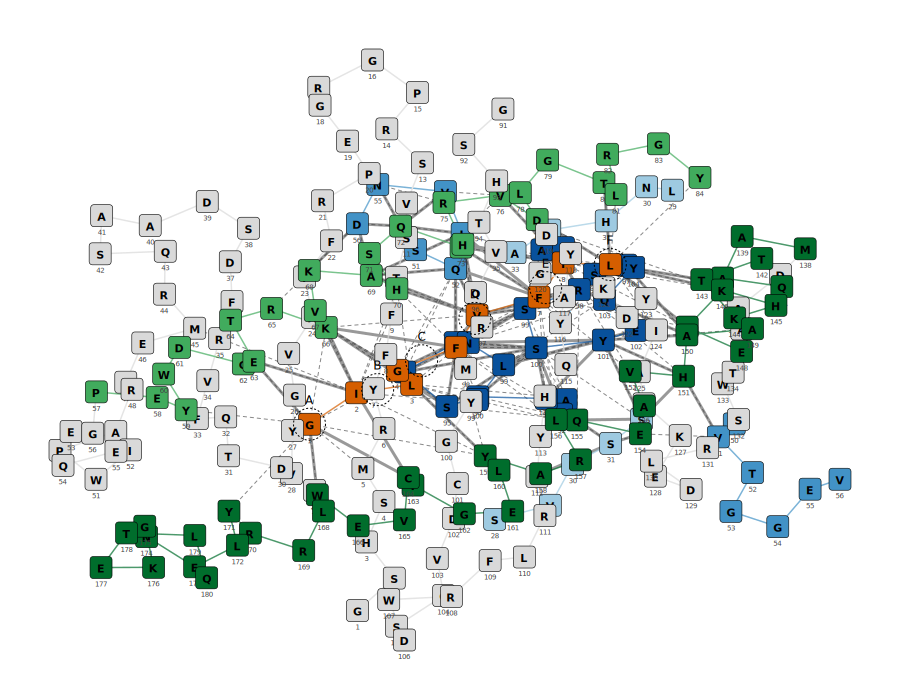

TCR (CDR1-3) ↔ peptide


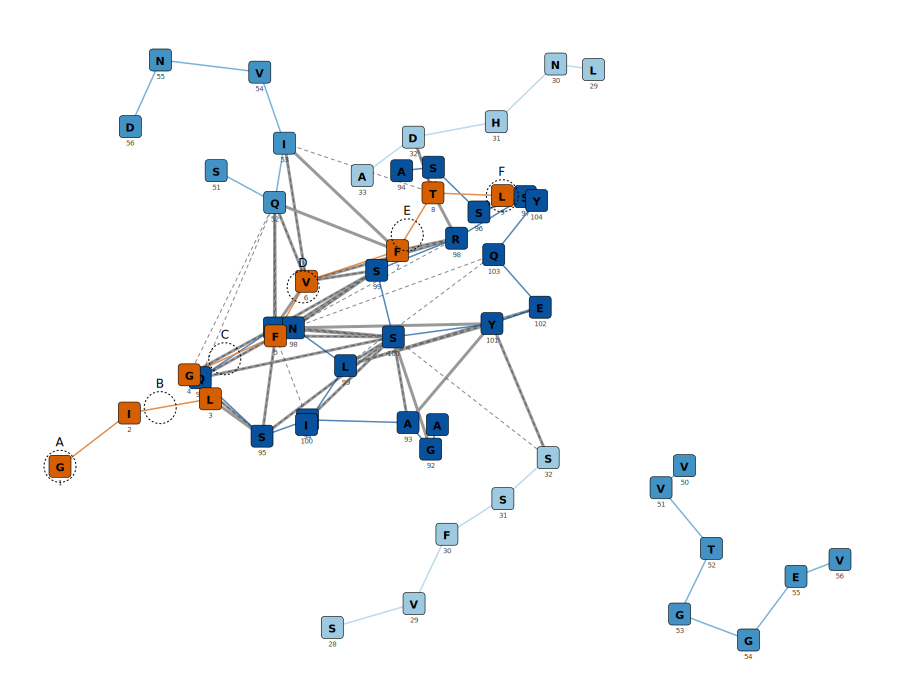

In [3]:
# Project onto the canonical groove plane and build the canonical tables.
proj = project_structure(s)
markup = residue_markup_table(s, proj)
contacts = contacts_table(s, threshold=5.0)
ca_contacts = ca_contacts_table(s, threshold=8.0)
pockets = pocket_markers(markup)
# Full map, then the focused TCR(CDR1-3)↔peptide footprint.
print('full interface'); display(SVG(render_complementarity_map(markup, contacts=contacts, ca_contacts=ca_contacts, pockets=pockets)))
print('TCR (CDR1-3) ↔ peptide'); display(SVG(render_complementarity_map(
    markup, contacts=contacts, ca_contacts=ca_contacts, pockets=pockets, show_chains=['tra', 'trb', 'peptide'])))

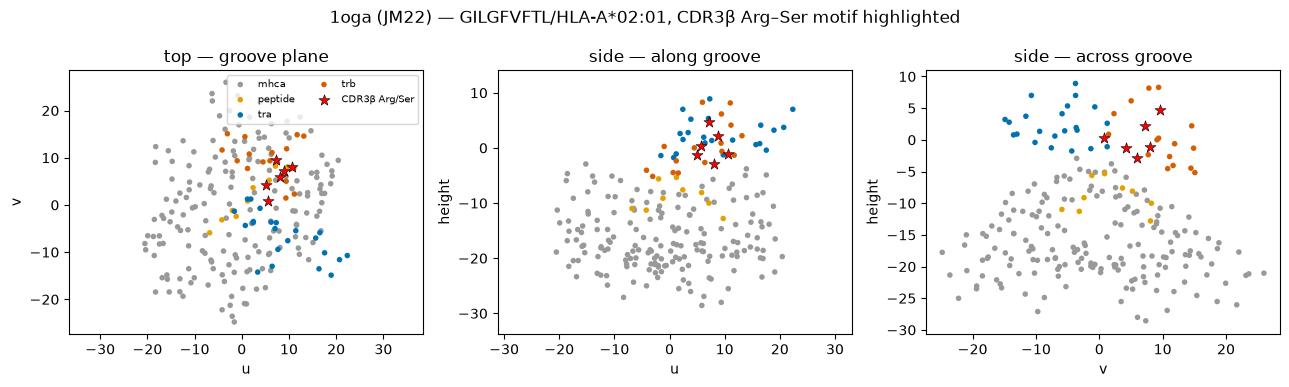

In [4]:
# Three orthogonal structural views; the CDR3β Arg/Ser residues highlighted in red.
m = markup.filter(pl.col('u').is_not_null())
chain_col = {'mhca': '#999999', 'mhcb': '#777777', 'peptide': '#E69F00', 'tra': '#0072B2', 'trb': '#D55E00'}
is_rs = (pl.col('complex_chain') == 'trb') & (pl.col('complex_region') == 'cdr3') & (pl.col('aa').is_in(['R', 'S']))
planes = [('u', 'v', 'top — groove plane'), ('u', 'height', 'side — along groove'), ('v', 'height', 'side — across groove')]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
for ax, (a1, a2, ttl) in zip(axes, planes):
    for ch, col in chain_col.items():
        sub = m.filter((pl.col('complex_chain') == ch) & ~is_rs)
        if sub.height:
            ax.scatter(sub[a1], sub[a2], s=16, c=col, label=ch, edgecolor='none')
    rs = m.filter(is_rs)
    if rs.height:
        ax.scatter(rs[a1], rs[a2], s=70, marker='*', c='red', label='CDR3β Arg/Ser', edgecolor='k', linewidth=0.4, zorder=5)
    ax.set_xlabel(a1); ax.set_ylabel(a2); ax.set_title(ttl); ax.set_aspect('equal', 'datalim')
axes[0].legend(fontsize=7, ncol=2, loc='best')
fig.suptitle('1oga (JM22) — GILGFVFTL/HLA-A*02:01, CDR3β Arg–Ser motif highlighted'); plt.tight_layout(); plt.show()

## Summary

Oriented into the canonical frame, the JM22 TCR docks GILGFVFTL/HLA-A*02:01 at a crossing angle in
the canonical αβ range. The complementarity map and the CDR3β→peptide contact table show the
conserved **Arg–Ser motif** of CDR3β reaching across the peptide — the structural correlate of the
public TRBV19 RS signature catalogued in VDJdb (Shugay *et al.*, *Nucleic Acids Research* 2018,
https://doi.org/10.1093/nar/gkx760; via PubMed). The same recipe — `import_structure` →
`classify_chains` → `annotate_mhc` → `project_structure` → `region_pair_contacts` /
`render_complementarity_map` — works for any TCR-pMHC complex in the HF set.